# Physics-Informed Neural Network for Spin-1/2 Precession

This notebook develops a **Physics-Informed Neural Network (PINN)** for the Bloch equations governing the precession of a spin-$\frac{1}{2}$ system in a static magnetic field.

Unlike a supervised neural network, the model is not trained on a dataset of reference trajectories. Its training objective is constructed from:

- the residuals of the Bloch equations,
- the initial spin condition,
- conservation of the Bloch-vector norm,
- conservation of the spin projection onto the magnetic-field direction.

Two configurations are investigated:

1. a magnetic field directed along the $z$-axis,
2. a magnetic field tilted by $45^\circ$ in the $xz$-plane.

For both cases, the PINN prediction is compared with an analytical solution. The tilted-field trajectory is also visualized on the Bloch sphere.

---

### Notebook outline

1. Physical background  
2. PINN architecture and automatic differentiation  
3. Physics-informed loss  
4. Experiment 1: field along the $z$-axis  
5. Experiment 2: tilted field  
6. Bloch-sphere visualization and conclusions

## 1. Setup and reproducibility

The project uses PyTorch for the neural network and automatic differentiation, NumPy for numerical analysis, and Matplotlib for visualization. Fixed random seeds make the results approximately reproducible.


In [ ]:
import copy
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [ ]:
SEED = 42
GAMMA = 1.0
T_MAX = 4.0 * math.pi
NUM_COLLOCATION_POINTS = 300
EPOCHS = 10_000
LEARNING_RATE = 5e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODELS_DIR = Path("models")
IMAGES_DIR = Path("images")
MODELS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

print("Device:", device)


Device: cpu


## 2. Physical background

### 2.1 Spin-$\frac{1}{2}$ and the Bloch vector

A pure state of a two-level quantum system can be represented by the Bloch vector

$$
\mathbf{S}(t)= \begin{pmatrix} S_x(t)\\ S_y(t)\\ S_z(t) \end{pmatrix}, \qquad \|\mathbf{S}(t)\|^2=1.
$$

Its components are expectation values of the Pauli operators,

$$
S_i(t)=\langle \sigma_i\rangle, \qquad i\in\{x,y,z\},
$$

where

$$
\sigma_x= \begin{pmatrix} 0&1\\ 1&0 \end{pmatrix}, \quad \sigma_y= \begin{pmatrix} 0&-i\\ i&0 \end{pmatrix}, \quad \sigma_z= \begin{pmatrix} 1&0\\ 0&-1 \end{pmatrix}.
$$

### 2.2 Magnetic interaction and Bloch equations

For the Hamiltonian

$$
H=-\frac{\hbar\gamma}{2}\,\mathbf{B}\cdot\mathbf{\sigma},
$$

the Bloch vector obeys

$$
\frac{d\mathbf{S}}{dt} = \gamma\,\mathbf{S}\times\mathbf{B}.
$$

Writing $\mathbf{B}=(B_x,B_y,B_z)$ gives

$$
\frac{dS_x}{dt}=\gamma(S_yB_z-S_zB_y),
$$

$$
\frac{dS_y}{dt}=\gamma(S_zB_x-S_xB_z),
$$

$$
\frac{dS_z}{dt}=\gamma(S_xB_y-S_yB_x).
$$

Dimensionless units are used throughout, with $\gamma=1$.

### 2.3 Conserved quantities

For a static magnetic field, the dynamics conserve

$$
\|\mathbf{S}(t)\|^2=1
$$

and

$$
\mathbf{S}(t)\cdot\hat{\mathbf{B}} = \mathbf{S}(0)\cdot\hat{\mathbf{B}}, \qquad \hat{\mathbf{B}}=\frac{\mathbf{B}}{\|\mathbf{B}\|}.
$$

These invariants are incorporated into the PINN loss.

### 2.4 Analytical solution

A constant magnetic field rotates the initial spin $\mathbf{S}_0$ around $\hat{\mathbf{B}}$. Rodrigues' rotation formula gives

$$
\mathbf{S}(t) = \mathbf{S}_0\cos\theta + (\mathbf{S}_0\times\hat{\mathbf{B}})\sin\theta + \hat{\mathbf{B}} (\mathbf{S}_0\cdot\hat{\mathbf{B}}) (1-\cos\theta),
$$

with

$$
\theta(t)=\gamma\|\mathbf{B}\|t.
$$



## 3. PINN architecture

The network approximates the mapping

$$
t\longmapsto (S_x(t),S_y(t),S_z(t)).
$$

The architecture is

$$
1 \rightarrow 64 \rightarrow 64 \rightarrow 64 \rightarrow 3.
$$

Smooth `Tanh` activations are used because the loss depends on derivatives of the network output with respect to time.


In [ ]:
class SpinPINN(nn.Module):
    """Multilayer perceptron approximating t -> (S_x, S_y, S_z)."""

    def __init__(
        self,
        hidden_dim: int = 64,
        num_hidden_layers: int = 3,
    ) -> None:
        super().__init__()

        layers = [
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
        ]

        for _ in range(num_hidden_layers - 1):
            layers.extend(
                [
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.Tanh(),
                ]
            )

        layers.append(nn.Linear(hidden_dim, 3))
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self) -> None:
        """Apply Xavier initialization to all linear layers."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.network(t)


## 4. Automatic differentiation and Bloch residuals

PyTorch's automatic-differentiation engine evaluates

$$
\frac{dS_x}{dt}, \qquad \frac{dS_y}{dt}, \qquad \frac{dS_z}{dt}.
$$

The derivatives are substituted into the Bloch equations to form residuals. A physically correct solution has residuals close to zero at every collocation point.


In [ ]:
def compute_spin_derivatives(
    model: nn.Module,
    t: torch.Tensor,
):
    """Return spin components and their derivatives with respect to time."""
    if not t.requires_grad:
        raise ValueError("Tensor t must have requires_grad=True.")

    spin = model(t)
    sx, sy, sz = (spin[:, i : i + 1] for i in range(3))

    def derivative(component: torch.Tensor) -> torch.Tensor:
        return torch.autograd.grad(
            outputs=component,
            inputs=t,
            grad_outputs=torch.ones_like(component),
            create_graph=True,
        )[0]

    return sx, sy, sz, derivative(sx), derivative(sy), derivative(sz)


def compute_bloch_residuals(
    model: nn.Module,
    t: torch.Tensor,
    magnetic_field: torch.Tensor,
    gamma: float = 1.0,
):
    """Evaluate the three residuals of the Bloch equations."""
    sx, sy, sz, dsx_dt, dsy_dt, dsz_dt = compute_spin_derivatives(
        model, t
    )

    field = magnetic_field.to(device=t.device, dtype=t.dtype)
    bx, by, bz = field

    residual_x = dsx_dt - gamma * (sy * bz - sz * by)
    residual_y = dsy_dt - gamma * (sz * bx - sx * bz)
    residual_z = dsz_dt - gamma * (sx * by - sy * bx)

    return residual_x, residual_y, residual_z


## 5. Physics-informed loss

The total loss is

$$
\mathcal{L} = \lambda_{\mathrm{physics}}\mathcal{L}_{\mathrm{physics}} + \lambda_{\mathrm{initial}}\mathcal{L}_{\mathrm{initial}} + \lambda_{\mathrm{norm}}\mathcal{L}_{\mathrm{norm}} + \lambda_{\mathrm{projection}}\mathcal{L}_{\mathrm{projection}}.
$$

The four terms enforce:

- the Bloch differential equations,
- the initial condition,
- the unit norm of the Bloch vector,
- the conserved projection onto the field direction.

The experiments use

$$
\lambda_{\mathrm{physics}}=5,\quad \lambda_{\mathrm{initial}}=10,\quad \lambda_{\mathrm{norm}}=5,\quad \lambda_{\mathrm{projection}}=10.
$$



In [ ]:
def physics_loss(
    model: nn.Module,
    t: torch.Tensor,
    magnetic_field: torch.Tensor,
    gamma: float = 1.0,
) -> torch.Tensor:
    residuals = compute_bloch_residuals(
        model=model,
        t=t,
        magnetic_field=magnetic_field,
        gamma=gamma,
    )
    return sum(torch.mean(residual**2) for residual in residuals)


def initial_condition_loss(
    model: nn.Module,
    initial_spin: torch.Tensor,
) -> torch.Tensor:
    t0 = torch.zeros(
        (1, 1),
        device=initial_spin.device,
        dtype=initial_spin.dtype,
    )
    return torch.mean((model(t0) - initial_spin) ** 2)


def normalization_loss(
    model: nn.Module,
    t: torch.Tensor,
) -> torch.Tensor:
    norm_squared = torch.sum(model(t) ** 2, dim=1, keepdim=True)
    return torch.mean((norm_squared - 1.0) ** 2)


def field_projection_loss(
    model: nn.Module,
    t: torch.Tensor,
    magnetic_field: torch.Tensor,
    initial_spin: torch.Tensor,
) -> torch.Tensor:
    field = magnetic_field.to(device=t.device, dtype=t.dtype)
    field_direction = field / torch.linalg.vector_norm(field)

    predicted_projection = model(t) @ field_direction.reshape(3, 1)
    expected_projection = initial_spin @ field_direction.reshape(3, 1)

    return torch.mean((predicted_projection - expected_projection) ** 2)


def total_loss(
    model: nn.Module,
    t: torch.Tensor,
    magnetic_field: torch.Tensor,
    initial_spin: torch.Tensor,
    gamma: float = 1.0,
    lambda_physics: float = 5.0,
    lambda_initial: float = 10.0,
    lambda_norm: float = 5.0,
    lambda_projection: float = 10.0,
):
    loss_phys = physics_loss(model, t, magnetic_field, gamma)
    loss_ic = initial_condition_loss(model, initial_spin)
    loss_norm = normalization_loss(model, t)
    loss_projection = field_projection_loss(
        model, t, magnetic_field, initial_spin
    )

    loss = (
        lambda_physics * loss_phys
        + lambda_initial * loss_ic
        + lambda_norm * loss_norm
        + lambda_projection * loss_projection
    )

    return loss, loss_phys, loss_ic, loss_norm, loss_projection


## 6. Training utility

The model is optimized with Adam. Gradient clipping limits unstable parameter updates, while the best state encountered during training is restored at the end.


In [ ]:
def train_pinn(
    model: nn.Module,
    magnetic_field: torch.Tensor,
    initial_spin: torch.Tensor,
    t_max: float = T_MAX,
    num_collocation_points: int = NUM_COLLOCATION_POINTS,
    epochs: int = EPOCHS,
    learning_rate: float = LEARNING_RATE,
    gamma: float = GAMMA,
    print_every: int = 1000,
):
    model_device = next(model.parameters()).device
    model_dtype = next(model.parameters()).dtype

    magnetic_field = magnetic_field.to(
        device=model_device,
        dtype=model_dtype,
    )
    initial_spin = initial_spin.to(
        device=model_device,
        dtype=model_dtype,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "total": [],
        "physics": [],
        "initial": [],
        "norm": [],
        "projection": [],
    }

    best_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        t_physics = torch.linspace(
            0.0,
            t_max,
            num_collocation_points,
            device=model_device,
            dtype=model_dtype,
        ).reshape(-1, 1)
        t_physics.requires_grad_(True)

        loss, loss_phys, loss_ic, loss_norm, loss_projection = total_loss(
            model=model,
            t=t_physics,
            magnetic_field=magnetic_field,
            initial_spin=initial_spin,
            gamma=gamma,
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        history["total"].append(loss.item())
        history["physics"].append(loss_phys.item())
        history["initial"].append(loss_ic.item())
        history["norm"].append(loss_norm.item())
        history["projection"].append(loss_projection.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.6e} | "
                f"Physics: {loss_phys.item():.6e} | "
                f"Initial: {loss_ic.item():.6e} | "
                f"Norm: {loss_norm.item():.6e} | "
                f"Projection: {loss_projection.item():.6e}"
            )

    model.load_state_dict(best_state)
    model.eval()
    return history


## 7. Experiment 1 — magnetic field along the $z$-axis

The first configuration is

$$
\mathbf{B}=(0,0,1), \qquad \mathbf{S}(0)=(1,0,0).
$$

The analytical solution is

$$
S_x(t)=\cos t, \qquad S_y(t)=-\sin t, \qquad S_z(t)=0.
$$

The trajectory is therefore a circle in the $xy$-plane.


In [ ]:
torch.manual_seed(SEED)

initial_spin = torch.tensor(
    [[1.0, 0.0, 0.0]],
    dtype=torch.float32,
    device=device,
)

z_field = torch.tensor(
    [0.0, 0.0, 1.0],
    dtype=torch.float32,
    device=device,
)

z_field_model = SpinPINN().to(device)

z_history = train_pinn(
    model=z_field_model,
    magnetic_field=z_field,
    initial_spin=initial_spin,
)


Epoch     0 | Total: 7.737310e+00 | Physics: 7.057136e-01 | Initial: 3.333333e-01 | Norm: 1.503706e-01 | Projection: 1.235564e-02
Epoch  1000 | Total: 5.580037e-01 | Physics: 1.023206e-01 | Initial: 2.865288e-04 | Norm: 8.654684e-03 | Projection: 2.621751e-05
Epoch  2000 | Total: 1.589834e-01 | Physics: 3.014598e-02 | Initial: 1.207270e-04 | Norm: 1.314985e-03 | Projection: 4.713498e-05
Epoch  3000 | Total: 3.421082e-02 | Physics: 6.409380e-03 | Initial: 1.596465e-05 | Norm: 3.820772e-04 | Projection: 9.388422e-06
Epoch  4000 | Total: 1.826660e-02 | Physics: 2.944723e-03 | Initial: 3.434759e-05 | Norm: 6.269022e-04 | Projection: 6.500206e-06
Epoch  5000 | Total: 7.948819e-03 | Physics: 1.189647e-03 | Initial: 6.664421e-06 | Norm: 3.635384e-04 | Projection: 1.162472e-05
Epoch  6000 | Total: 2.734608e-03 | Physics: 3.350711e-04 | Initial: 1.362693e-05 | Norm: 1.545023e-04 | Projection: 1.504714e-05
Epoch  7000 | Total: 2.059594e-03 | Physics: 2.218192e-04 | Initial: 5.296410e-06 | Norm: 

### 7.1 Training history


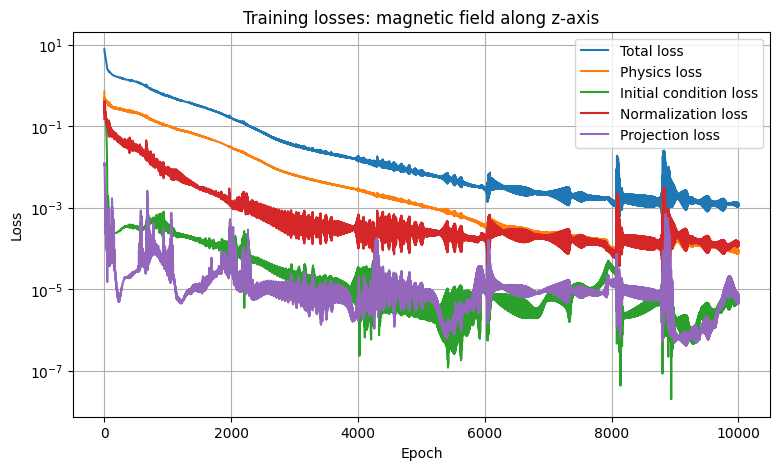

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, values in z_history.items():
    ax.plot(values, label=name.capitalize())

ax.set(
    xlabel="Epoch",
    ylabel="Loss",
    title="Training losses: magnetic field along the z-axis",
    yscale="log",
)
ax.grid(True)
ax.legend()
plt.show()


### 7.2 Comparison with the analytical solution


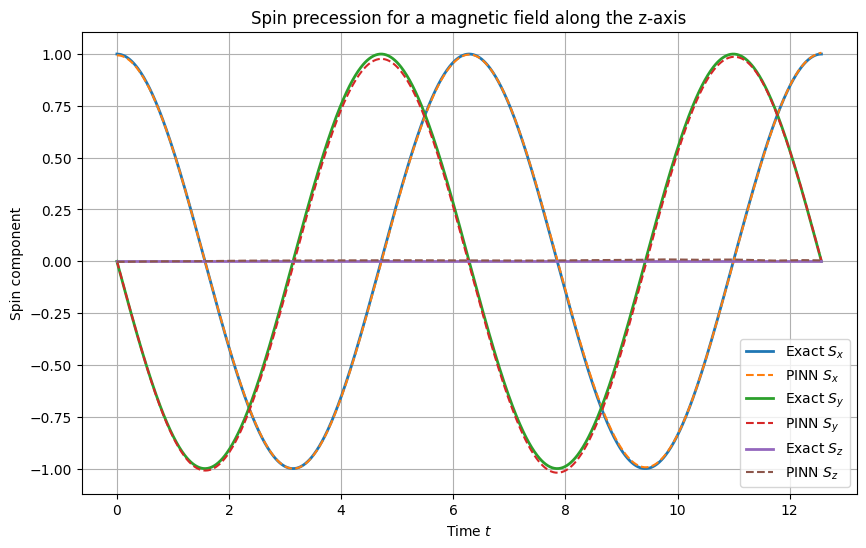

MAE Sx: 3.680033e-03
MAE Sy: 1.619973e-02
MAE Sz: 4.507932e-03

Max error Sx: 8.903325e-03
Max error Sy: 2.555603e-02
Max error Sz: 9.104254e-03

Mean norm error: 2.066996e-02
Maximum norm error: 4.633260e-02


In [ ]:
z_field_model.eval()

t_test = torch.linspace(
    0.0,
    T_MAX,
    1000,
    device=device,
).reshape(-1, 1)

with torch.no_grad():
    spin_pred = z_field_model(t_test)

t_np = t_test[:, 0].cpu().numpy()
sx_pred, sy_pred, sz_pred = spin_pred.cpu().numpy().T

sx_exact = np.cos(t_np)
sy_exact = -np.sin(t_np)
sz_exact = np.zeros_like(t_np)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_np, sx_exact, label="Exact $S_x$", linewidth=2)
ax.plot(t_np, sx_pred, "--", label="PINN $S_x$")
ax.plot(t_np, sy_exact, label="Exact $S_y$", linewidth=2)
ax.plot(t_np, sy_pred, "--", label="PINN $S_y$")
ax.plot(t_np, sz_exact, label="Exact $S_z$", linewidth=2)
ax.plot(t_np, sz_pred, "--", label="PINN $S_z$")

ax.set(
    xlabel="Time $t$",
    ylabel="Spin component",
    title="Spin precession for a magnetic field along the $z$-axis",
)
ax.grid(True)
ax.legend()

fig.savefig(
    IMAGES_DIR / "z_field_solution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

pred_matrix = np.column_stack((sx_pred, sy_pred, sz_pred))
exact_matrix = np.column_stack((sx_exact, sy_exact, sz_exact))
absolute_error = np.abs(pred_matrix - exact_matrix)

mae = absolute_error.mean(axis=0)
max_error = absolute_error.max(axis=0)

print(f"MAE Sx: {mae[0]:.6e}")
print(f"MAE Sy: {mae[1]:.6e}")
print(f"MAE Sz: {mae[2]:.6e}")
print()
print(f"Max error Sx: {max_error[0]:.6e}")
print(f"Max error Sy: {max_error[1]:.6e}")
print(f"Max error Sz: {max_error[2]:.6e}")

norm_squared = sx_pred**2 + sy_pred**2 + sz_pred**2
norm_error = np.abs(norm_squared - 1.0)

print()
print(f"Mean norm error: {norm_error.mean():.6e}")
print(f"Maximum norm error: {norm_error.max():.6e}")


### 7.3 Conservation of the Bloch-vector norm


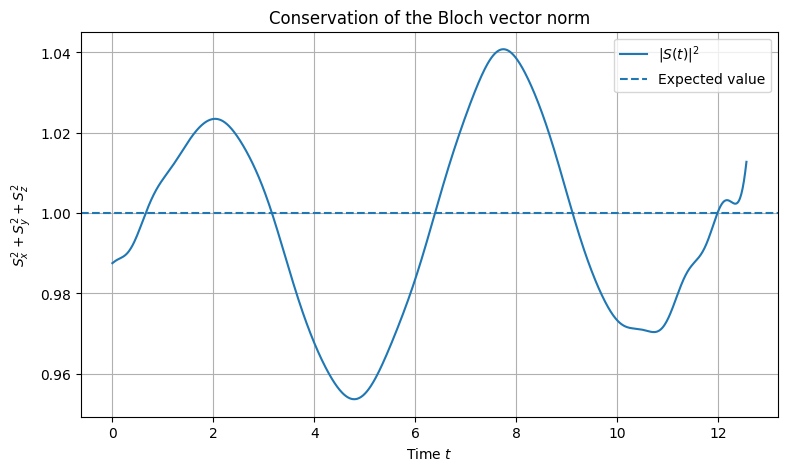

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_np, norm_squared, label=r"$|\mathbf{S}(t)|^2$")
ax.axhline(1.0, linestyle="--", label="Expected value")

ax.set(
    xlabel="Time $t$",
    ylabel="$S_x^2+S_y^2+S_z^2$",
    title="Conservation of the Bloch-vector norm",
)
ax.grid(True)
ax.legend()

fig.savefig(
    IMAGES_DIR / "z_field_norm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:
torch.save(
    z_field_model.state_dict(),
    MODELS_DIR / "z_field_spin_pinn.pt",
)

print("Saved: models/z_field_spin_pinn.pt")


Model saved.


## 8. Experiment 2 — tilted magnetic field

The second field is normalized and tilted by $45^\circ$ in the $xz$-plane:

$$
\mathbf{B} = \left( \frac{1}{\sqrt{2}}, 0, \frac{1}{\sqrt{2}} \right).
$$

All three spin components may now vary. The spin precesses around the tilted field direction while preserving its norm and its projection onto $\hat{\mathbf{B}}$.


In [ ]:
torch.manual_seed(SEED)

tilted_field = torch.tensor(
    [
        1.0 / math.sqrt(2.0),
        0.0,
        1.0 / math.sqrt(2.0),
    ],
    dtype=torch.float32,
    device=device,
)

tilted_field_model = SpinPINN().to(device)

tilted_history = train_pinn(
    model=tilted_field_model,
    magnetic_field=tilted_field,
    initial_spin=initial_spin,
)


Epoch     0 | Total: 1.216018e+01 | Physics: 7.012907e-01 | Initial: 3.333333e-01 | Norm: 1.503706e-01 | Projection: 4.568538e-01
Epoch  1000 | Total: 3.923187e-01 | Physics: 3.527812e-02 | Initial: 5.148486e-06 | Norm: 1.461034e-02 | Projection: 1.428249e-02
Epoch  2000 | Total: 2.644292e-01 | Physics: 3.685039e-02 | Initial: 3.258976e-05 | Norm: 7.754868e-03 | Projection: 4.107696e-03
Epoch  3000 | Total: 2.002670e-01 | Physics: 3.294517e-02 | Initial: 1.199422e-04 | Norm: 2.183414e-03 | Projection: 2.342469e-03
Epoch  4000 | Total: 1.443316e-01 | Physics: 2.301625e-02 | Initial: 4.436758e-04 | Norm: 4.347954e-03 | Projection: 3.073887e-04
Epoch  5000 | Total: 7.444359e-02 | Physics: 1.357753e-02 | Initial: 3.225363e-05 | Norm: 1.073102e-03 | Projection: 8.678730e-05
Epoch  6000 | Total: 3.245876e-02 | Physics: 5.940211e-03 | Initial: 4.167480e-05 | Norm: 2.731003e-04 | Projection: 9.754549e-05
Epoch  7000 | Total: 5.925906e-03 | Physics: 9.383153e-04 | Initial: 4.769447e-06 | Norm: 

### 8.1 Training history


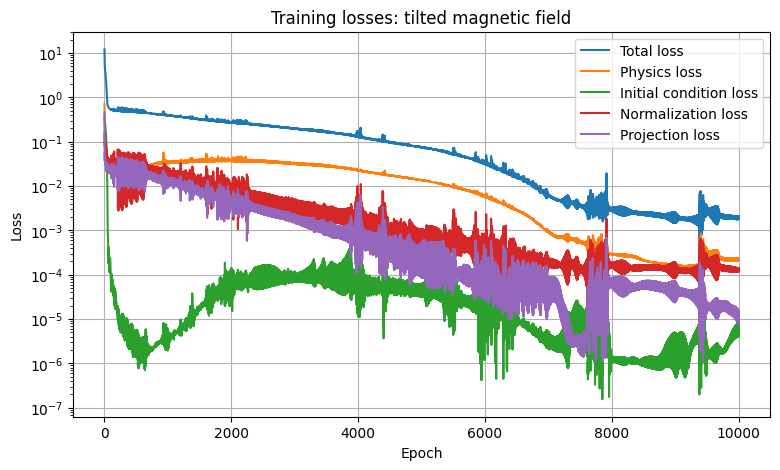

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, values in tilted_history.items():
    ax.plot(values, label=name.capitalize())

ax.set(
    xlabel="Epoch",
    ylabel="Loss",
    title="Training losses: tilted magnetic field",
    yscale="log",
)
ax.grid(True)
ax.legend()
plt.show()


### 8.2 Analytical comparison and physical invariants


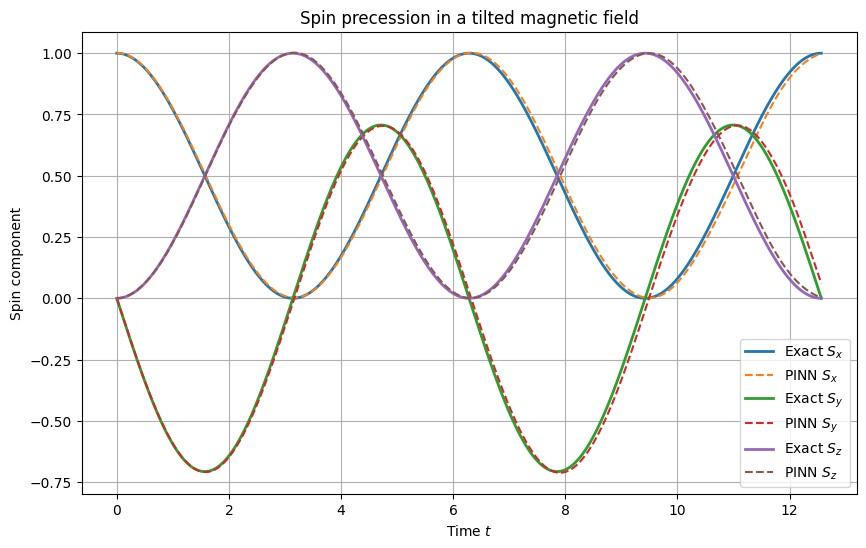

MAE Sx: 1.395126e-02
MAE Sy: 1.962253e-02
MAE Sz: 1.402572e-02

Max error Sx: 4.027289e-02
Max error Sy: 6.070121e-02
Max error Sz: 4.052371e-02

Mean norm error: 3.699170e-03
Maximum norm error: 1.040637e-02
Mean field-projection error: 2.097618e-03
Maximum field-projection error: 4.174948e-03


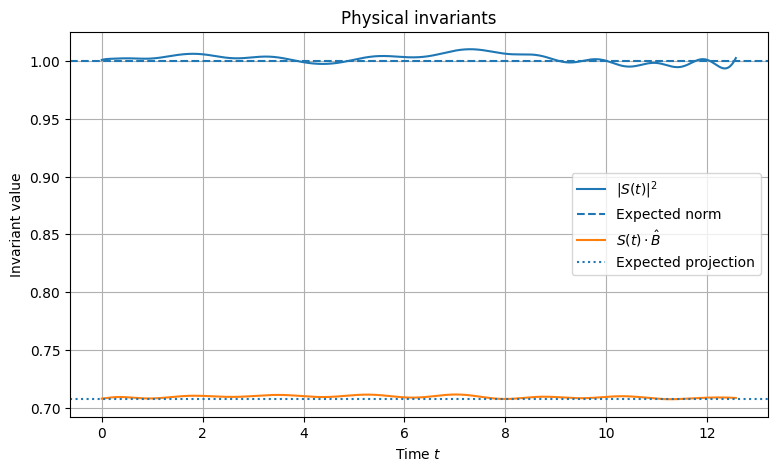

In [ ]:
tilted_field_model.eval()

t_test = torch.linspace(
    0.0,
    T_MAX,
    1000,
    device=device,
).reshape(-1, 1)

with torch.no_grad():
    spin_pred = tilted_field_model(t_test)

field_direction = tilted_field / torch.linalg.vector_norm(tilted_field)
field_norm = torch.linalg.vector_norm(tilted_field)
s0 = initial_spin.reshape(3)
theta = GAMMA * field_norm * t_test

spin_exact = (
    torch.cos(theta) * s0
    + torch.sin(theta) * torch.cross(s0, field_direction, dim=0)
    + (1.0 - torch.cos(theta))
    * torch.dot(s0, field_direction)
    * field_direction
)

t_np = t_test[:, 0].cpu().numpy()
pred_np = spin_pred.cpu().numpy()
exact_np = spin_exact.cpu().numpy()

sx_pred, sy_pred, sz_pred = pred_np.T
sx_exact, sy_exact, sz_exact = exact_np.T

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_np, sx_exact, label="Exact $S_x$", linewidth=2)
ax.plot(t_np, sx_pred, "--", label="PINN $S_x$")
ax.plot(t_np, sy_exact, label="Exact $S_y$", linewidth=2)
ax.plot(t_np, sy_pred, "--", label="PINN $S_y$")
ax.plot(t_np, sz_exact, label="Exact $S_z$", linewidth=2)
ax.plot(t_np, sz_pred, "--", label="PINN $S_z$")

ax.set(
    xlabel="Time $t$",
    ylabel="Spin component",
    title="Spin precession in a tilted magnetic field",
)
ax.grid(True)
ax.legend()

fig.savefig(
    IMAGES_DIR / "tilted_field_solution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

absolute_error = np.abs(pred_np - exact_np)

print(f"MAE Sx: {absolute_error[:, 0].mean():.6e}")
print(f"MAE Sy: {absolute_error[:, 1].mean():.6e}")
print(f"MAE Sz: {absolute_error[:, 2].mean():.6e}")
print()
print(f"Max error Sx: {absolute_error[:, 0].max():.6e}")
print(f"Max error Sy: {absolute_error[:, 1].max():.6e}")
print(f"Max error Sz: {absolute_error[:, 2].max():.6e}")

field_direction_np = field_direction.cpu().numpy()
norm_squared = np.sum(pred_np**2, axis=1)
projection = pred_np @ field_direction_np
expected_projection = float(torch.dot(s0, field_direction).cpu())

norm_error = np.abs(norm_squared - 1.0)
projection_error = np.abs(projection - expected_projection)

print()
print(f"Mean norm error: {norm_error.mean():.6e}")
print(f"Maximum norm error: {norm_error.max():.6e}")
print(f"Mean field-projection error: {projection_error.mean():.6e}")
print(f"Maximum field-projection error: {projection_error.max():.6e}")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_np, norm_squared, label=r"$|\mathbf{S}(t)|^2$")
ax.axhline(1.0, linestyle="--", label="Expected norm")
ax.plot(t_np, projection, label=r"$\mathbf{S}(t)\cdot\hat{\mathbf{B}}$")
ax.axhline(
    expected_projection,
    linestyle=":",
    label="Expected projection",
)

ax.set(
    xlabel="Time $t$",
    ylabel="Invariant value",
    title="Physical invariants",
)
ax.grid(True)
ax.legend()

fig.savefig(
    IMAGES_DIR / "tilted_field_invariants.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### 8.3 Bloch-sphere trajectory


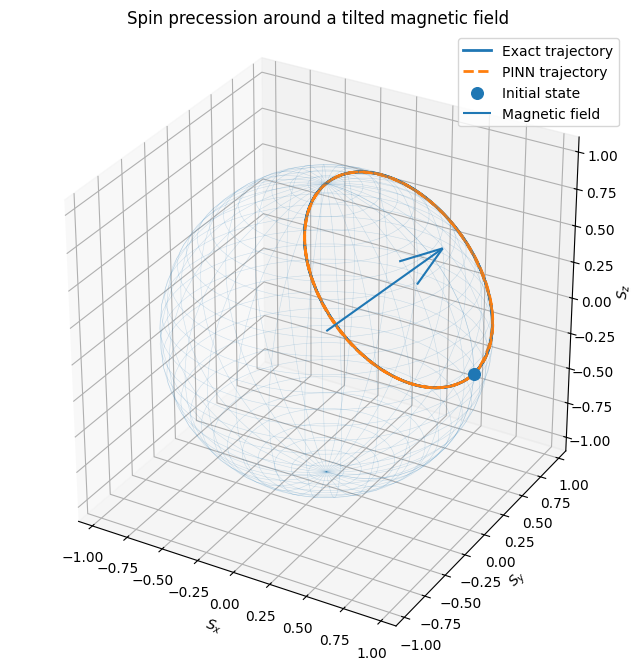

In [ ]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

u = np.linspace(0.0, 2.0 * np.pi, 60)
v = np.linspace(0.0, np.pi, 30)

sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(
    sphere_x,
    sphere_y,
    sphere_z,
    linewidth=0.4,
    alpha=0.2,
)

ax.plot(
    exact_np[:, 0],
    exact_np[:, 1],
    exact_np[:, 2],
    linewidth=2,
    label="Exact trajectory",
)
ax.plot(
    pred_np[:, 0],
    pred_np[:, 1],
    pred_np[:, 2],
    "--",
    linewidth=2,
    label="PINN trajectory",
)
ax.scatter(
    pred_np[0, 0],
    pred_np[0, 1],
    pred_np[0, 2],
    s=70,
    label="Initial state",
)
ax.quiver(
    0.0,
    0.0,
    0.0,
    field_direction_np[0],
    field_direction_np[1],
    field_direction_np[2],
    length=1.1,
    normalize=True,
    label="Magnetic field",
)

ax.set(
    xlabel="$S_x$",
    ylabel="$S_y$",
    zlabel="$S_z$",
    title="Spin precession around a tilted magnetic field",
)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
ax.set_box_aspect((1, 1, 1))
ax.legend()

fig.savefig(
    IMAGES_DIR / "bloch_sphere_tilted_field.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:
torch.save(
    tilted_field_model.state_dict(),
    MODELS_DIR / "tilted_field_spin_pinn.pt",
)

print("Saved: models/tilted_field_spin_pinn.pt")
print("Saved figures in: images/")


Model and Bloch-sphere figure saved.


## 9. Conclusions

The PINN successfully reproduces spin precession for both static-field configurations.

### Main observations

- The predicted trajectories closely follow the analytical solutions.
- Automatic differentiation provides the time derivatives required by the Bloch equations.
- The differential-equation residual alone is not sufficient for reliable long-time dynamics.
- Enforcing the Bloch-vector norm prevents artificial amplitude decay.
- Enforcing the field projection prevents the model from drifting toward an incorrect precession axis.

Representative errors from the displayed runs are of order $10^{-2}$ for the spin components. In the tilted-field experiment, both physical invariants remain close to their exact values over the full interval $t\in[0,4\pi]$.

### Possible extensions

- time-dependent magnetic fields and Rabi oscillations,
- longitudinal and transverse relaxation ($T_1$ and $T_2$),
- inverse estimation of an unknown field or gyromagnetic ratio,
- adaptive collocation-point sampling,
- comparison with Runge–Kutta solvers,
- coupled multi-spin systems.
